In [1]:
!pip install pandas numpy matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import random

In [3]:
np.random.seed(42)

categories = [
    "Food", "Transport", "Shopping", "Bills", "Entertainment", "Health"
]

payment_methods = ["Cash", "UPI", "Credit Card", "Debit Card"]

start_date = datetime(2025, 1, 1)

data = []

for i in range(200):
    date = start_date + timedelta(days=random.randint(0, 150))
    category = random.choice(categories)
    payment = random.choice(payment_methods)

    amount = round(random.uniform(50, 3000), 2)

    data.append([date, category, payment, amount])

df = pd.DataFrame(data, columns=["Date", "Category", "Payment_Method", "Amount"])

df.head()

,Date,Category,Payment_Method,Amount
0,2025-01-30,Bills,Cash,2971.02
1,2025-02-03,Shopping,UPI,868.74
2,2025-04-27,Transport,Cash,520.00
3,2025-03-08,Health,UPI,2711.77
4,2025-04-22,Shopping,UPI,2028.46


In [4]:
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.to_period("M")

df.head()

,Date,Category,Payment_Method,Amount,Month
0,2025-01-30,Bills,Cash,2971.02,2025-01
1,2025-02-03,Shopping,UPI,868.74,2025-02
2,2025-04-27,Transport,Cash,520.00,2025-04
3,2025-03-08,Health,UPI,2711.77,2025-03
4,2025-04-22,Shopping,UPI,2028.46,2025-04


In [5]:
print("Total Spending:", df["Amount"].sum())

print("\nCategory-wise Spending:")
print(df.groupby("Category")["Amount"].sum())

print("\nPayment Method Analysis:")
print(df.groupby("Payment_Method")["Amount"].sum())

Total Spending: 301826.1

Category-wise Spending:
Category
Bills            52504.93
Entertainment    37934.07
Food             64574.82
Health           60073.88
Shopping         50448.13
Transport        36290.27
Name: Amount, dtype: float64

Payment Method Analysis:
Payment_Method
Cash           64038.20
Credit Card    71539.30
Debit Card     67466.47
UPI            98782.13
Name: Amount, dtype: float64


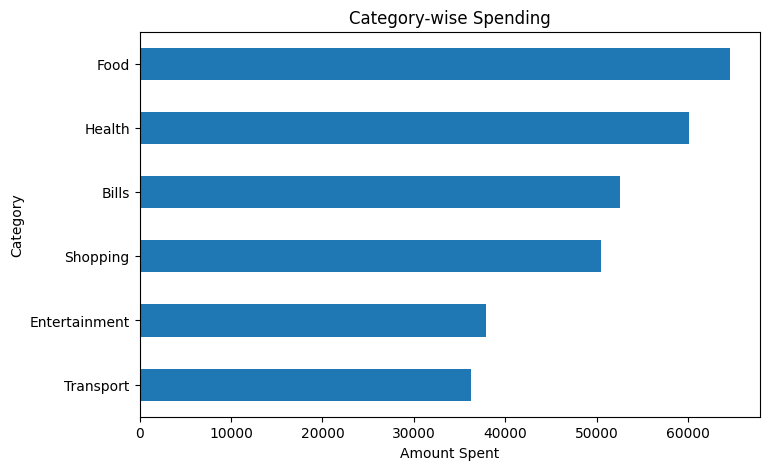

In [6]:
plt.figure(figsize=(8,5))
df.groupby("Category")["Amount"].sum().sort_values().plot(kind="barh")
plt.title("Category-wise Spending")
plt.xlabel("Amount Spent")
plt.show()

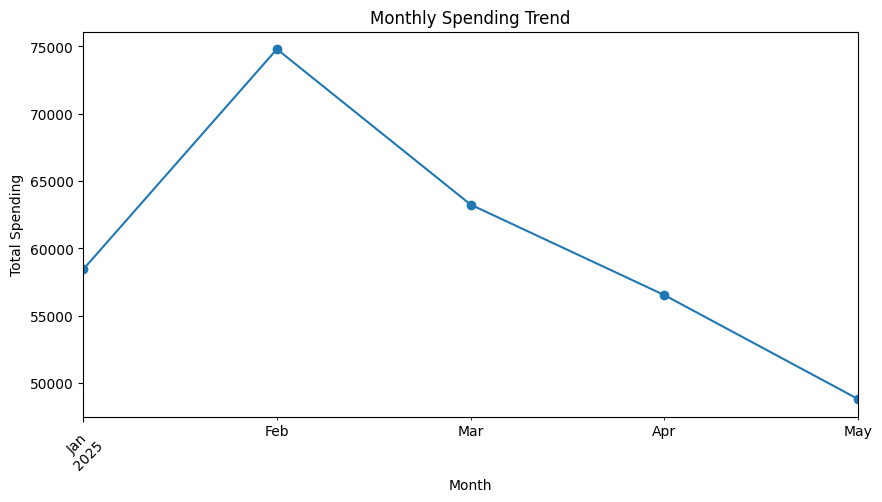

In [7]:
monthly = df.groupby("Month")["Amount"].sum()

plt.figure(figsize=(10,5))
monthly.plot(marker="o")
plt.title("Monthly Spending Trend")
plt.xlabel("Month")
plt.ylabel("Total Spending")
plt.xticks(rotation=45)
plt.show()

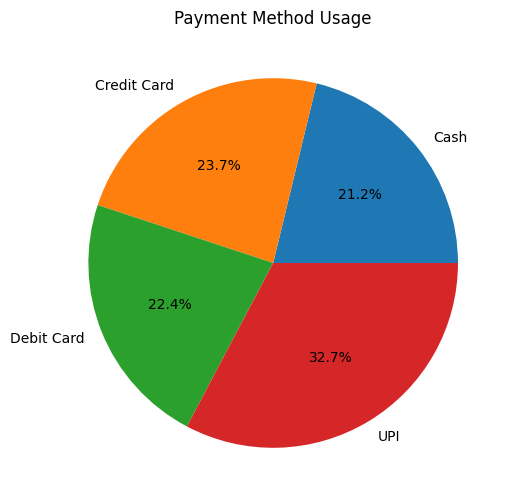

In [8]:
payment = df.groupby("Payment_Method")["Amount"].sum()

plt.figure(figsize=(6,6))
plt.pie(payment, labels=payment.index, autopct="%1.1f%%")
plt.title("Payment Method Usage")
plt.show()

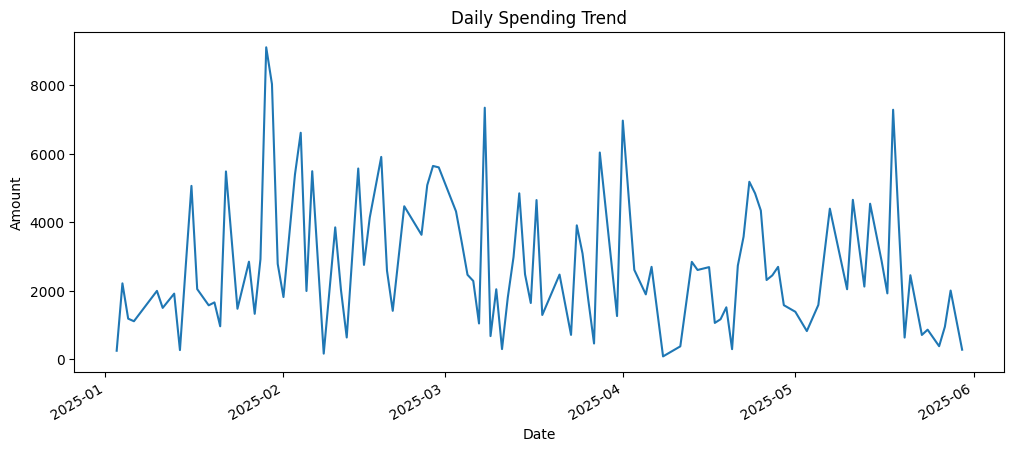

In [9]:
daily = df.groupby("Date")["Amount"].sum()

plt.figure(figsize=(12,5))
daily.plot()
plt.title("Daily Spending Trend")
plt.xlabel("Date")
plt.ylabel("Amount")
plt.show()

In [10]:
top_days = df.groupby("Date")["Amount"].sum().sort_values(ascending=False).head(10)
print(top_days)

Date
2025-01-29    9114.24
2025-01-30    8038.78
2025-03-08    7349.08
2025-05-18    7289.47
2025-04-01    6971.83
2025-02-04    6616.88
2025-03-28    6039.41
2025-02-18    5910.73
2025-02-27    5646.39
2025-02-28    5605.08
Name: Amount, dtype: float64


In [11]:
df.to_csv("expense_data.csv", index=False)
print("File saved as expense_data.csv")

File saved as expense_data.csv


In [12]:
print("==== FINAL INSIGHTS ====")
print("Total Expense:", df["Amount"].sum())
print("Highest Spending Category:", df.groupby("Category")["Amount"].sum().idxmax())
print("Highest Payment Method:", df.groupby("Payment_Method")["Amount"].sum().idxmax())
print("Average Daily Spending:", df.groupby("Date")["Amount"].sum().mean())

==== FINAL INSIGHTS ====
Total Expense: 301826.1
Highest Spending Category: Food
Highest Payment Method: UPI
Average Daily Spending: 2769.046788990825
